# Propiedades geométricas de contornos

En este cuaderno vas a medir propiedades geométricas sobre formas simples. El objetivo es que cada medida tenga una interpretación clara antes de llevarla a escenas más complejas.


## Objetivo

Calcular área, perímetro, caja contenedora, centroide y cantidad aproximada de vértices sobre contornos bien controlados.

## Resultados de aprendizaje

Al finalizar este cuaderno, vas a poder:

- calcular medidas geométricas básicas de un contorno;
- interpretar qué describe cada medida;
- relacionar la forma observada con la cantidad de vértices aproximados;
- preparar el terreno para analizar objetos reales.

## Relación con la secuencia

Este cuaderno continúa el trabajo sobre contornos. Primero se aprende a detectar el borde; ahora se pasa a describirlo con medidas.


## Módulos que vamos a usar

- `cv2`: para detectar contornos y calcular medidas geométricas.
- `numpy`: para construir un lienzo binario.
- `matplotlib.pyplot`: para mostrar anotaciones.


In [1]:
import cv2 #se usa para dibujar formas, detectar contornos y calcular medidas geométricas
import numpy as np #se usa para crear el lienzo, que en este caso es una matriz de píxeles
import matplotlib.pyplot as plt #se usa para mostrar las imágenes dentro del notebook


## 1. Construir un caso controlado

Vamos a trabajar con un rectángulo, un círculo y un triángulo sobre fondo negro. Eso permite que cada medida se lea con mucha más claridad que en una escena real con ruido.


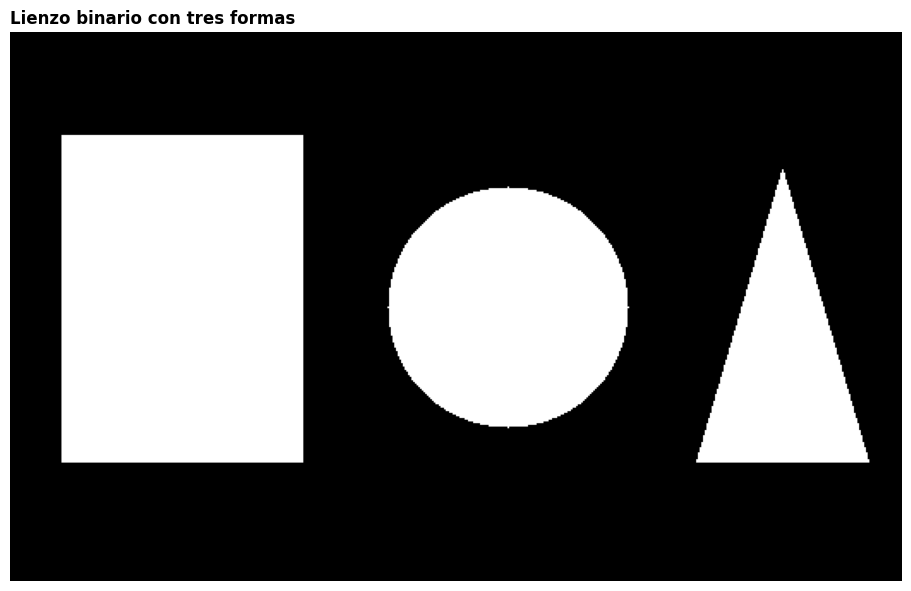

In [2]:
lienzo = np.zeros((320, 520), dtype=np.uint8) #image negra de 320 alto x 520 pixeles de ancho
cv2.rectangle(lienzo, (30, 60), (170, 250), 255, -1) #Dibuja un rectángulo blanco sobre el lienzo, esquina, esquina opuesta, color blanco, relleno completo
cv2.circle(lienzo, (290, 160), 70, 255, -1) #Dibuja un círculo blanco relleno, centro (290,160), radio 70, color blanco grosor de relleno
vertices_triangulo = np.array([[400, 250], [500, 250], [450, 80]], dtype=np.int32) #Define los tres vértices del triángulo como un arreglo de NumPy
cv2.fillPoly(lienzo, [vertices_triangulo], 255) #Dibuja y rellena el polígono definido por esos vértices

plt.figure(figsize=(9, 6), constrained_layout=True)
plt.imshow(lienzo, cmap="gray")
plt.title("Lienzo binario con tres formas", fontweight="bold", loc="left")
plt.axis("off")
plt.show()


## 2. Medir cada contorno

Ahora vamos a detectar los contornos y a calcular varias propiedades. La idea es que cada medida tenga una lectura geométrica concreta.


In [3]:
contornos, _ = cv2.findContours(lienzo.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE) #busca los bordes de la imagen, hace una copia, le pide a OpenCV que recupere solo los contornos externos y guarde los cambios de manera mas eficiente
contornos = sorted(contornos, key=cv2.contourArea, reverse=True) #Ordena los contornos de mayor a menor área y hace más consistente la lectura de resultados

def medir_contorno(contorno): #Calcula el área encerrada por el contorno indicando cuántos píxeles ocupa la figura
    area = cv2.contourArea(contorno)
    perimetro = cv2.arcLength(contorno, True) #Calcula la longitud del borde del contorno
    x, y, ancho, alto = cv2.boundingRect(contorno) #Es el rectángulo más chico, alineado horizontal y verticalmente, que contiene toda la figura

    momentos = cv2.moments(contorno) #Calcula los momentos geométricos del contorno que permiten obtener propiedades como el centroide
    centro_x = int(momentos["m10"] / momentos["m00"])
    centro_y = int(momentos["m01"] / momentos["m00"]) #Calcula el centro geométrico de la figura

    epsilon = 0.03 * perimetro #Simplifica el contorno y lo aproxima por un polígono
    aproximacion = cv2.approxPolyDP(contorno, epsilon, True) #Cuenta cuántos vértices tiene la aproximación dando una pista sobre la forma

    return { #Devuelve todas las medidas juntas en un diccionario
        "area": area,
        "perimetro": perimetro,
        "caja": (x, y, ancho, alto),
        "centroide": (centro_x, centro_y),
        "vertices_aproximados": len(aproximacion),
    }

mediciones = [medir_contorno(contorno) for contorno in contornos] #Crea una lista donde cada elemento contiene las medidas de una figura


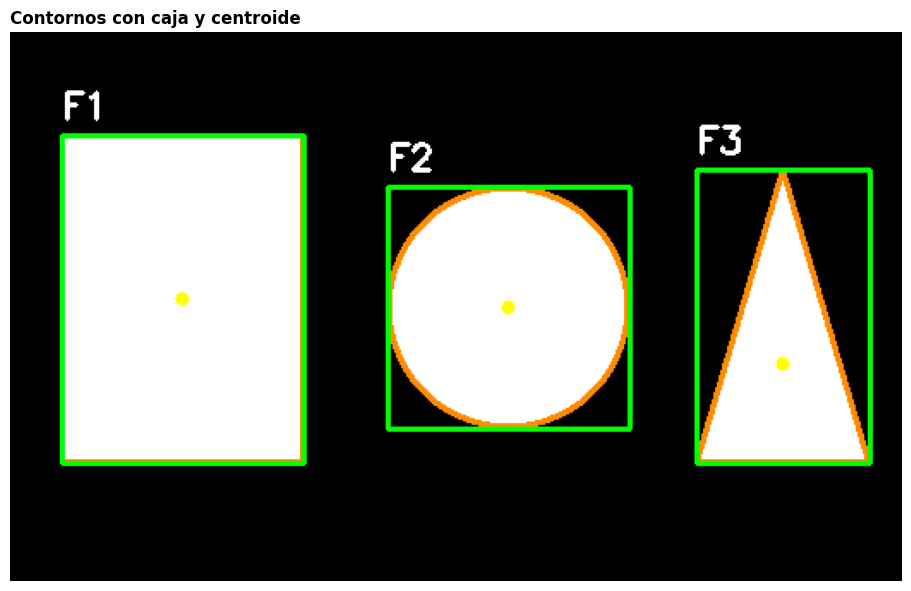

In [4]:
imagen_anotada = cv2.cvtColor(lienzo, cv2.COLOR_GRAY2RGB) #Convierte la imagen en grises a RGB

for indice, (contorno, medicion) in enumerate(zip(contornos, mediciones), start=1): #Recorre simultáneamente cada contorno, sus mediciones y enumera las figuras
    x, y, ancho, alto = medicion["caja"]
    centro_x, centro_y = medicion["centroide"]
    cv2.drawContours(imagen_anotada, [contorno], -1, (255, 140, 0), 2)
    cv2.rectangle(imagen_anotada, (x, y), (x + ancho, y + alto), (0, 255, 0), 2)
    cv2.circle(imagen_anotada, (centro_x, centro_y), 4, (255, 255, 0), -1)
    cv2.putText(imagen_anotada, f"F{indice}", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

plt.figure(figsize=(9, 6), constrained_layout=True)
plt.imshow(imagen_anotada)
plt.title("Contornos con caja y centroide", fontweight="bold", loc="left")
plt.axis("off")
plt.show()


In [5]:
for indice, medicion in enumerate(mediciones, start=1): #Recorre todas las mediciones y las imprime en texto
    print(f"Forma {indice}")
    print(f"  Área: {medicion['area']:.1f} píxeles cuadrados")
    print(f"  Perímetro: {medicion['perimetro']:.1f} píxeles")
    print(f"  Caja: {medicion['caja']}")
    print(f"  Centroide: {medicion['centroide']}")
    print(f"  Vértices aproximados: {medicion['vertices_aproximados']}")
    print()


Forma 1
  Área: 26600.0 píxeles cuadrados
  Perímetro: 660.0 píxeles
  Caja: (30, 60, 141, 191)
  Centroide: (100, 155)
  Vértices aproximados: 4

Forma 2
  Área: 15176.0 píxeles cuadrados
  Perímetro: 461.6 píxeles
  Caja: (220, 90, 141, 141)
  Centroide: (290, 160)
  Vértices aproximados: 8

Forma 3
  Área: 8500.0 píxeles cuadrados
  Perímetro: 481.4 píxeles
  Caja: (400, 80, 101, 171)
  Centroide: (450, 193)
  Vértices aproximados: 3



La cantidad de vértices aproximados no identifica mágicamente la figura, pero sí da una pista geométrica útil. En una escena simple, esa información se interpreta rápido. En una escena real, suele combinarse con otras medidas.


El notebook construye una imagen binaria con tres figuras simples y luego detecta sus contornos externos. Sobre cada contorno calcula propiedades geométricas básicas: área, perímetro, caja contenedora, centroide y cantidad aproximada de vértices. Finalmente, esas medidas se muestran tanto de forma visual como numérica, para relacionar la geometría observada con valores cuantificables

## Actividad breve

Agregá una cuarta forma al lienzo y repetí la medición. Después describí:

1. cómo cambió el área;
2. qué te dice la caja contenedora;
3. si la aproximación por vértices ayuda o no a reconocer la forma.


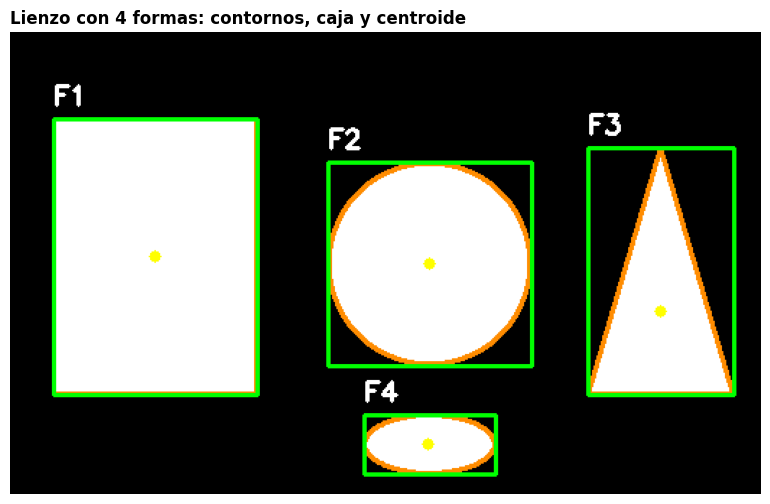

Forma 1
  Área: 26600.0 píxeles cuadrados
  Perímetro: 660.0 píxeles
  Caja contenedora: (30, 60, 141, 191)
  Centroide: (100, 155)
  Vértices aproximados: 4

Forma 2
  Área: 15176.0 píxeles cuadrados
  Perímetro: 461.6 píxeles
  Caja contenedora: (220, 90, 141, 141)
  Centroide: (290, 160)
  Vértices aproximados: 8

Forma 3
  Área: 8500.0 píxeles cuadrados
  Perímetro: 481.4 píxeles
  Caja contenedora: (400, 80, 101, 171)
  Centroide: (450, 193)
  Vértices aproximados: 3

Forma 4
  Área: 2824.0 píxeles cuadrados
  Perímetro: 222.5 píxeles
  Caja contenedora: (245, 265, 91, 41)
  Centroide: (289, 285)
  Vértices aproximados: 8



In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#Crear lienzo binario
lienzo = np.zeros((320, 520), dtype=np.uint8)

#Dibujar las 3 formas originales
cv2.rectangle(lienzo, (30, 60), (170, 250), 255, -1)  # rectángulo
cv2.circle(lienzo, (290, 160), 70, 255, -1)           # círculo

vertices_triangulo = np.array(
    [[400, 250], [500, 250], [450, 80]],
    dtype=np.int32
)
cv2.fillPoly(lienzo, [vertices_triangulo], 255)       # triángulo


#Agregar cuarta forma: elipse

cv2.ellipse(lienzo, (290, 285), (45, 20), 0, 0, 360, 255, -1)


#Buscar contornos externos
contornos, _ = cv2.findContours(lienzo.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contornos = sorted(contornos, key=cv2.contourArea, reverse=True)


#Función para medir cada contorno

def medir_contorno(contorno):
    area = cv2.contourArea(contorno)
    perimetro = cv2.arcLength(contorno, True)
    x, y, ancho, alto = cv2.boundingRect(contorno)

    momentos = cv2.moments(contorno)
    if momentos["m00"] != 0:
        centro_x = int(momentos["m10"] / momentos["m00"])
        centro_y = int(momentos["m01"] / momentos["m00"])
    else:
        centro_x, centro_y = 0, 0

    epsilon = 0.03 * perimetro
    aproximacion = cv2.approxPolyDP(contorno, epsilon, True)

    return {
        "area": area,
        "perimetro": perimetro,
        "caja": (x, y, ancho, alto),
        "centroide": (centro_x, centro_y),
        "vertices_aproximados": len(aproximacion),
    }

mediciones = [medir_contorno(contorno) for contorno in contornos]


#Crear imagen anotada en color

imagen_anotada = cv2.cvtColor(lienzo, cv2.COLOR_GRAY2RGB)

for indice, (contorno, medicion) in enumerate(zip(contornos, mediciones), start=1):
    x, y, ancho, alto = medicion["caja"]
    centro_x, centro_y = medicion["centroide"]

    # Contorno
    cv2.drawContours(imagen_anotada, [contorno], -1, (255, 140, 0), 2)

    # Caja contenedora
    cv2.rectangle(imagen_anotada, (x, y), (x + ancho, y + alto), (0, 255, 0), 2)

    # Centroide
    cv2.circle(imagen_anotada, (centro_x, centro_y), 4, (255, 255, 0), -1)

    # Etiqueta
    cv2.putText(
        imagen_anotada,
        f"F{indice}",
        (x, max(y - 10, 15)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 255, 255),
        2
    )


#Mostrar resultado visual

plt.figure(figsize=(10, 6))
plt.imshow(imagen_anotada)
plt.title("Lienzo con 4 formas: contornos, caja y centroide", fontweight="bold", loc="left")
plt.axis("off")
plt.show()


#Imprimir métricas

for indice, medicion in enumerate(mediciones, start=1):
    print(f"Forma {indice}")
    print(f"  Área: {medicion['area']:.1f} píxeles cuadrados")
    print(f"  Perímetro: {medicion['perimetro']:.1f} píxeles")
    print(f"  Caja contenedora: {medicion['caja']}")
    print(f"  Centroide: {medicion['centroide']}")
    print(f"  Vértices aproximados: {medicion['vertices_aproximados']}")
    print()

### Conclusiones

Al agregar una cuarta forma, aumentó la cantidad de contornos detectados y apareció una nueva medición de área y perímetro.  
La caja contenedora permite estimar la posición y el tamaño máximo de cada figura, aunque en formas curvas incluye zonas vacías que no pertenecen realmente al objeto.  
La aproximación por vértices resulta muy útil en figuras poligonales, como el triángulo o el rectángulo, pero es menos representativa en una elipse, porque al ser una forma curva la cantidad de vértices depende del nivel de simplificación aplicado.

## Cierre

Medir un contorno es una forma de pasar del borde visible a una descripción cuantitativa. Esa transición es importante porque permite comparar objetos, clasificarlos y construir reglas más precisas sobre la forma observada.
